# Amazon Delivery Optimization
## Multi-Objective Optimization Analysis

**Student Name:** Simon Zychowski

**Target Company/Industry:** Amazon/Delivery

**Problem:** I aim to optimize the main delivery objectives of Amazon drivers

**Objectives:** Minimize fulfillment and delivery cost per order vs. Maximize delivery speed and on time performance

---


## Brief Project Overview
Amazon’s business model depends on fast, reliable shipping, but increasing delivery speed significantly raises costs. Faster delivery requires more fulfillment centers closer to customers, higher inventory levels, and more expensive transportation methods like air shipping or same-day logistics. At the same time, Amazon must control these costs to remain profitable, especially as its fulfillment network continues to expand. This creates a constant tension between offering faster delivery and maintaining cost efficiency.

---

## Section 1: Data Acquisition

In [2]:
import pandas as pd

# Load the data
df = pd.read_csv('data/delivery_data.csv')

# Display first rows
print("Data loaded successfully!")
print(f"Shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())


Data loaded successfully!
Shape: (150, 9)

First 5 rows:
   order_id  distance_km  warehouse_load_pct  inventory_available  \
0         1       349.75                53.8                    0   
1         2       146.64                86.4                    1   
2         3       117.29                60.2                    0   
3         4       277.90                61.2                    0   
4         5       361.14                80.3                    1   

  transport_mode  delivery_time_hours  shipping_cost_usd  on_time_delivery  \
0            air                 21.9             103.98                 1   
1            air                  5.4              49.43                 1   
2       same_day                 17.3              59.56                 1   
3       same_day                 18.8             105.27                 1   
4         ground                 18.3              44.07                 1   

  customer_density  
0              low  
1             hig

## Section 2: Data Exploration

In [3]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Check data types
print("\nData types:")
print(df.dtypes)

# Basic statistics
print("\nBasic statistics:")
print(df.describe())


Missing values:
order_id               0
distance_km            0
warehouse_load_pct     0
inventory_available    0
transport_mode         0
delivery_time_hours    0
shipping_cost_usd      0
on_time_delivery       0
customer_density       0
dtype: int64

Data types:
order_id                 int64
distance_km            float64
warehouse_load_pct     float64
inventory_available      int64
transport_mode             str
delivery_time_hours    float64
shipping_cost_usd      float64
on_time_delivery         int64
customer_density           str
dtype: object

Basic statistics:
         order_id  distance_km  warehouse_load_pct  inventory_available  \
count  150.000000   150.000000          150.000000           150.000000   
mean    75.500000   256.323667           70.918000             0.873333   
std     43.445368   128.251936           16.141747             0.333713   
min      1.000000     6.330000           45.300000             0.000000   
25%     38.250000   161.872500           56.07

In [5]:
# Decision Variable 1: distance (continuous)
print(f"Distance range: {df['distance_km'].min()} to {df['distance_km'].max()}")

# Decision Variable 2: transport mode (categorical)
print(f"Transport modes: {df['transport_mode'].unique()}")

# Check total combinations (rows)
print(f"\nTotal combinations: {len(df)}")

# Count how many of each transport mode
print("\nTransport mode distribution:")
print(df['transport_mode'].value_counts())

# Optional: check combinations of mode + density (useful for constraints)
print("\nMode + Density combinations:")
print(df.groupby(['transport_mode', 'customer_density']).size())

Distance range: 6.33 to 497.7
Transport modes: <StringArray>
['air', 'same_day', 'ground']
Length: 3, dtype: str

Total combinations: 150

Transport mode distribution:
transport_mode
ground      86
air         44
same_day    20
Name: count, dtype: int64

Mode + Density combinations:
transport_mode  customer_density
air             high                11
                low                 11
                medium              22
ground          high                14
                low                 26
                medium              46
same_day        high                 7
                low                  2
                medium              11
dtype: int64


In [9]:
# Check the ranges of both objectives
print(f"Objective 1 (Shipping Cost) range: {df['shipping_cost_usd'].min()} to {df['shipping_cost_usd'].max()}")
print(f"Objective 2 (Delivery Time) range: {df['delivery_time_hours'].min()} to {df['delivery_time_hours'].max()}")

# Verify they create a tradeoff
correlation = df['shipping_cost_usd'].corr(df['delivery_time_hours'])
print(f"\nCorrelation between objectives: {correlation:.3f}")
print("(Negative correlation suggests a tradeoff)")

if abs(correlation) < 0.2:
    print("Weak relationship → tradeoff exists but influenced by multiple factors")
elif correlation > 0:
    print("Positive correlation → faster delivery tends to cost more (realistic tradeoff)")
else:
    print("Negative correlation → higher cost slightly reduces delivery time (tradeoff present)")

Objective 1 (Shipping Cost) range: 7.18 to 135.58
Objective 2 (Delivery Time) range: 2.5 to 36.1

Correlation between objectives: -0.142
(Negative correlation suggests a tradeoff)
Weak relationship → tradeoff exists but influenced by multiple factors


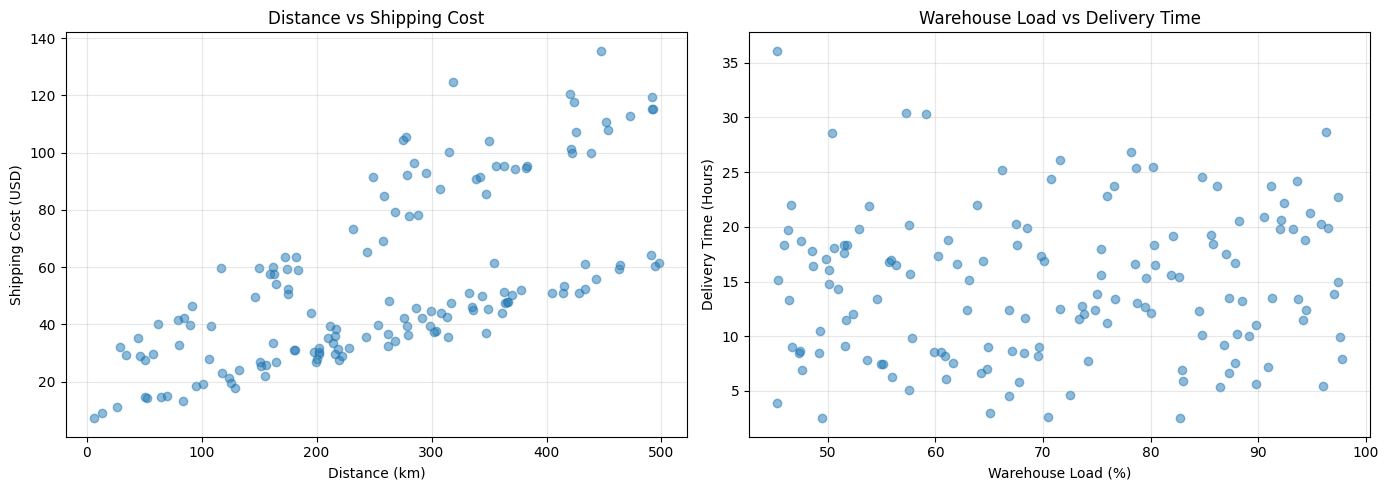

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: How distance affects cost
axes[0].scatter(df['distance_km'], df['shipping_cost_usd'], alpha=0.5)
axes[0].set_xlabel('Distance (km)')
axes[0].set_ylabel('Shipping Cost (USD)')
axes[0].set_title('Distance vs Shipping Cost')
axes[0].grid(True, alpha=0.3)

# Plot 2: How warehouse load affects delivery time
axes[1].scatter(df['warehouse_load_pct'], df['delivery_time_hours'], alpha=0.5)
axes[1].set_xlabel('Warehouse Load (%)')
axes[1].set_ylabel('Delivery Time (Hours)')
axes[1].set_title('Warehouse Load vs Delivery Time')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('images/data_exploration.png', dpi=300, bbox_inches='tight')
plt.show()

## Section 2: Summary

The ranges do look realistic, the objectives create a realistic tradeoff. Not one that is glaringly obvious but one that is indicative of real world data, showing that multiple factors cause the shifts in cost and delivery times, instead of it being one straightforward relation. The data is clean and isnt missing any rows. And yes my data aligns with the expectations from my proposal, other than I did shift to synthetic data for ease of use.

## Section 3: Pareto Frontier Calculation

In [11]:
def is_pareto_optimal(idx, df, obj1_col, obj2_col):
    current_obj1 = df.loc[idx, obj1_col]
    current_obj2 = df.loc[idx, obj2_col]
    
    for other_idx in df.index:
        if other_idx == idx:
            continue
        
        other_obj1 = df.loc[other_idx, obj1_col]
        other_obj2 = df.loc[other_idx, obj2_col]
        
        # Minimization version (correct for your case)
        if (other_obj1 <= current_obj1 and 
            other_obj2 <= current_obj2 and
            (other_obj1 < current_obj1 or other_obj2 < current_obj2)):
            return False
    
    return True

In [12]:
# Define your objective column names
OBJECTIVE_1 = 'shipping_cost_usd'
OBJECTIVE_2 = 'delivery_time_hours'

print("Calculating Pareto frontier...")
print("This may take a moment for large datasets...")

# Apply Pareto check to all rows
df['is_pareto_optimal'] = df.index.map(
    lambda idx: is_pareto_optimal(idx, df, OBJECTIVE_1, OBJECTIVE_2)
)

# Separate into frontier and dominated points
pareto_df = df[df['is_pareto_optimal']].copy()
dominated_df = df[~df['is_pareto_optimal']].copy()

print("\n=== PARETO FRONTIER RESULTS ===")
print(f"Total solutions analyzed: {len(df)}")
print(f"Pareto optimal solutions: {len(pareto_df)}")
print(f"Dominated solutions: {len(dominated_df)}")
print(f"Efficiency rate: {100 * len(pareto_df) / len(df):.1f}% of solutions are on the frontier")

Calculating Pareto frontier...
This may take a moment for large datasets...

=== PARETO FRONTIER RESULTS ===
Total solutions analyzed: 150
Pareto optimal solutions: 4
Dominated solutions: 146
Efficiency rate: 2.7% of solutions are on the frontier


## Section 3: Summary

Approximately 2.7% of the solutions are on the frontier

This is what I expected as this is just within the range for realistic or well formatted data and shows clear places with optimal solutions

This tells me that the tradeoff structure is rather strict and given that there are multiple variables that go into the cost of shipping this makes sense

## Section 3.5: Inefficient Solutions Analysis

## Section 4: Strategic Analysis

## Section 5: Visualization